# LightGBM — Playground Series S6E4: Predicting Irrigation Need

LightGBM with three named hyperparameter configurations plus Optuna tuning.
Reports macro F1, accuracy, and balanced accuracy (competition metric).

LightGBM uses **leaf-wise (best-first) tree growth**, splitting the leaf with the highest loss reduction rather than growing level-by-level. This can learn complex patterns faster but risks overfitting on small datasets — regularization and subsampling become important controls.

In [1]:
!ls /kaggle/input/

competitions


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             classification_report)

from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')
print(f'Train: {train.shape}, Test: {test.shape}')

Train: (630000, 21), Test: (270000, 20)


In [4]:
# preprocessing — LightGBM handles categoricals natively via 'category' dtype
X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']
X_test = test.drop(columns=['id'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

target_le = LabelEncoder()
y_enc = target_le.fit_transform(y)
print('Classes:', dict(zip(target_le.classes_, range(len(target_le.classes_)))))
print(f'\nClass distribution:')
for cls, idx in zip(target_le.classes_, range(len(target_le.classes_))):
    count = (y_enc == idx).sum()
    print(f'  {cls}: {count:,} ({count/len(y_enc)*100:.1f}%)')

Classes: {'High': 0, 'Low': 1, 'Medium': 2}

Class distribution:
  High: 21,009 (3.3%)
  Low: 369,917 (58.7%)
  Medium: 239,074 (37.9%)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
def evaluate_config(name, params, X_tr, y_tr, skf, target_le):
    """Run 5-fold CV and return macro F1, accuracy, balanced accuracy, and per-class recall."""
    f1s, accs, baccs = [], [], []
    per_class_recalls = {cls: [] for cls in target_le.classes_}

    for tr_idx, va_idx in skf.split(X_tr, y_tr):
        Xf_tr, Xf_va = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        yf_tr, yf_va = y_tr[tr_idx], y_tr[va_idx]

        m = LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
        m.fit(Xf_tr, yf_tr)
        p = m.predict(Xf_va)

        f1s.append(f1_score(yf_va, p, average='macro'))
        accs.append(accuracy_score(yf_va, p))
        baccs.append(balanced_accuracy_score(yf_va, p))

        for idx, cls in enumerate(target_le.classes_):
            mask = yf_va == idx
            if mask.sum() > 0:
                per_class_recalls[cls].append((p[mask] == idx).mean())

    print(f'{name}')
    print(f'  Macro F1:          {np.mean(f1s):.4f} (+/- {np.std(f1s):.4f})')
    print(f'  Accuracy:          {np.mean(accs):.4f} (+/- {np.std(accs):.4f})')
    print(f'  Balanced Accuracy: {np.mean(baccs):.4f} (+/- {np.std(baccs):.4f})')
    print(f'  Per-class recall:')
    recall_dict = {}
    for cls in target_le.classes_:
        r = np.mean(per_class_recalls[cls])
        recall_dict[cls] = r
        print(f'    {cls}: {r:.4f}')
    print()

    return {'name': name, 'macro_f1': np.mean(f1s), 'accuracy': np.mean(accs),
            'balanced_accuracy': np.mean(baccs),
            'recall_High': recall_dict['High'],
            'recall_Low': recall_dict['Low'],
            'recall_Medium': recall_dict['Medium']}

---
## Hyperparameter Configuration 1: Shallow trees, high learning rate

**Goal:** Establish a fast, simple baseline to measure how much more complex configs improve.

**Key choices:**
- `num_leaves=15`, `max_depth=4` — limits tree complexity, likely underfitting on a 19-feature dataset
- `learning_rate=0.2` with only 200 estimators — large steps, fewer trees
- No class weighting — the model sees class frequencies as-is (58.7% Low, 38% Medium, 3.3% High)
- No regularization or subsampling

**Expected behavior:** Decent overall accuracy (dominated by Low/Medium) but poor recall on the "High" class since the model has no incentive to learn the minority class.

In [7]:
config1_params = {
    'n_estimators': 200,
    'learning_rate': 0.2,
    'num_leaves': 15,
    'max_depth': 4,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0,
    'reg_lambda': 0,
}
r1 = evaluate_config('Config 1: Shallow + Fast (no class weight)',
                     config1_params, X_train, y_train, skf, target_le)

Config 1: Shallow + Fast (no class weight)
  Macro F1:          0.9695 (+/- 0.0010)
  Accuracy:          0.9845 (+/- 0.0004)
  Balanced Accuracy: 0.9614 (+/- 0.0015)
  Per-class recall:
    High: 0.9147
    Low: 0.9951
    Medium: 0.9743



---
## Hyperparameter Configuration 2: Deep trees, low learning rate, balanced

**Goal:** Test the combined effect of increasing model capacity *and* addressing class imbalance.

**Key changes from Config 1:**
- `num_leaves=63`, `max_depth=8` — much deeper trees that can capture more complex feature interactions
- `learning_rate=0.05` with 600 estimators — smaller steps, more trees for gradual convergence
- `class_weight='balanced'` — automatically upweights the rare "High" class (17:1 imbalance ratio)
- `subsample=0.8`, `colsample_bytree=0.8` — mild stochasticity to reduce overfitting from deeper trees

**Expected behavior:** Balanced accuracy should jump significantly due to class weighting improving High recall. Overall accuracy may drop slightly since the model now "pays more attention" to the rare class at the cost of some Low/Medium precision.

In [8]:
config2_params = {
    'n_estimators': 600,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 0,
    'class_weight': 'balanced',
}
r2 = evaluate_config('Config 2: Deep + Slow + Balanced',
                     config2_params, X_train, y_train, skf, target_le)

Config 2: Deep + Slow + Balanced
  Macro F1:          0.9680 (+/- 0.0008)
  Accuracy:          0.9842 (+/- 0.0003)
  Balanced Accuracy: 0.9664 (+/- 0.0015)
  Per-class recall:
    High: 0.9322
    Low: 0.9948
    Medium: 0.9723



---
## Hyperparameter Configuration 3: Regularized with heavy subsampling

**Goal:** Test whether regularization improves generalization compared to Config 2's deeper, unregularized trees.

**Key changes from Config 2:**
- `reg_alpha=5.0`, `reg_lambda=5.0` — L1 and L2 penalties on leaf weights to prevent overfitting
- `subsample=0.7`, `colsample_bytree=0.7` — more aggressive subsampling than Config 2
- `min_child_samples=30` — requires more data per leaf, preventing splits on tiny subgroups
- Moderate depth (`num_leaves=31`, `max_depth=6`) — between Config 1 and Config 2

**Expected behavior:** If Config 2 was overfitting, this should show a higher or comparable balanced accuracy with lower variance across folds. If Config 2 was not overfitting, regularization may slightly hurt performance by being too restrictive.

In [9]:
config3_params = {
    'n_estimators': 400,
    'learning_rate': 0.08,
    'num_leaves': 31,
    'max_depth': 6,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'reg_alpha': 5.0,
    'reg_lambda': 5.0,
    'min_child_samples': 30,
    'class_weight': 'balanced',
}
r3 = evaluate_config('Config 3: Regularized + Subsampled + Balanced',
                     config3_params, X_train, y_train, skf, target_le)

Config 3: Regularized + Subsampled + Balanced
  Macro F1:          0.9641 (+/- 0.0013)
  Accuracy:          0.9833 (+/- 0.0003)
  Balanced Accuracy: 0.9695 (+/- 0.0015)
  Per-class recall:
    High: 0.9448
    Low: 0.9947
    Medium: 0.9691



---
## Hyperparameter comparison

In [10]:
comparison = pd.DataFrame([r1, r2, r3]).set_index('name')
comparison = comparison.round(4)
print(comparison.to_markdown())

| name                                          |   macro_f1 |   accuracy |   balanced_accuracy |   recall_High |   recall_Low |   recall_Medium |
|:----------------------------------------------|-----------:|-----------:|--------------------:|--------------:|-------------:|----------------:|
| Config 1: Shallow + Fast (no class weight)    |     0.9695 |     0.9845 |              0.9614 |        0.9147 |       0.9951 |          0.9743 |
| Config 2: Deep + Slow + Balanced              |     0.968  |     0.9842 |              0.9664 |        0.9322 |       0.9948 |          0.9723 |
| Config 3: Regularized + Subsampled + Balanced |     0.9641 |     0.9833 |              0.9695 |        0.9448 |       0.9947 |          0.9691 |


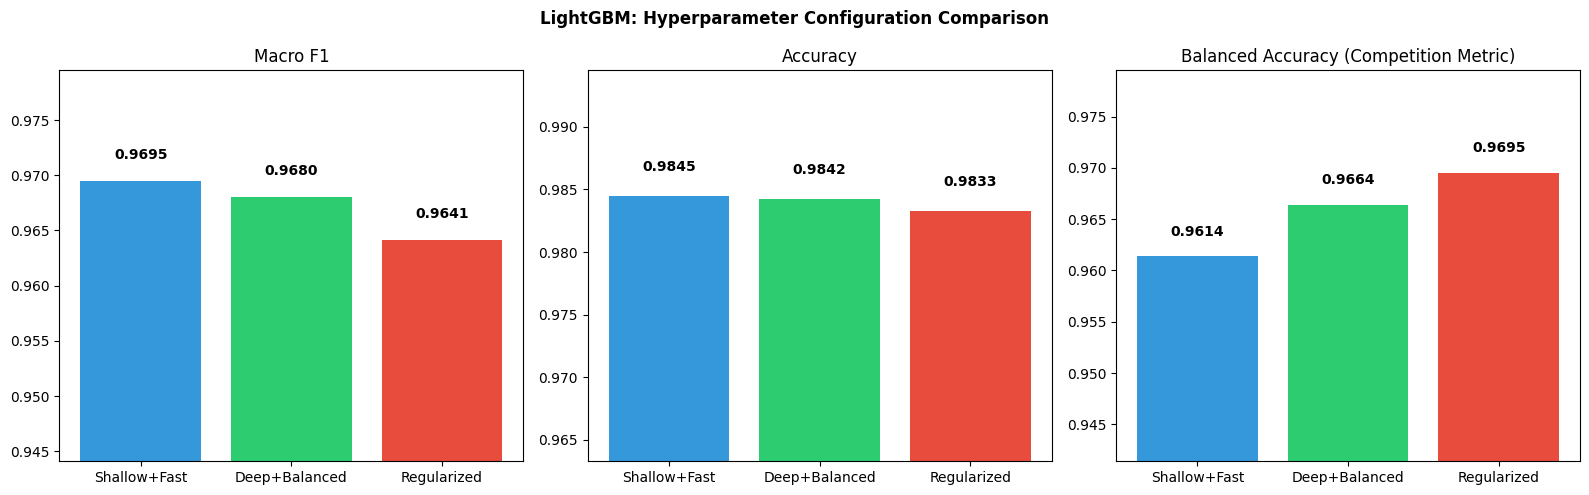

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['macro_f1', 'accuracy', 'balanced_accuracy']
titles = ['Macro F1', 'Accuracy', 'Balanced Accuracy (Competition Metric)']
labels = ['Shallow+Fast', 'Deep+Balanced', 'Regularized']

for ax, metric, title in zip(axes, metrics, titles):
    vals = comparison[metric].values
    bars = ax.bar(labels, vals, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax.set_title(title)
    ax.set_ylim(min(vals) - 0.02, max(vals) + 0.01)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('LightGBM: Hyperparameter Configuration Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

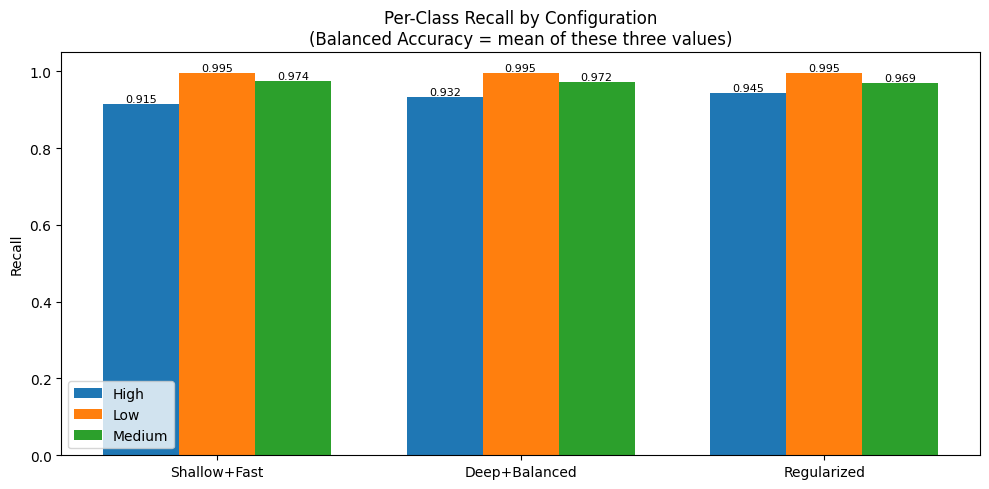

In [12]:
# per-class recall comparison — shows WHERE each config wins or loses
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.25

for i, cls in enumerate(['High', 'Low', 'Medium']):
    vals = comparison[f'recall_{cls}'].values
    ax.bar(x + i*width, vals, width, label=cls)
    for j, v in enumerate(vals):
        ax.text(x[j] + i*width, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Shallow+Fast', 'Deep+Balanced', 'Regularized'])
ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall by Configuration\n(Balanced Accuracy = mean of these three values)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Interpretation

Adding `class_weight="balanced"` was the single most impactful change. Config 1 (no class weighting) achieved a balanced accuracy of 0.9614 with High recall at just 0.9147 — the model was largely coasting on the majority classes. Config 2 added class weighting and deeper trees, pushing balanced accuracy to 0.9664 and High recall to 0.9322. The improvement came almost entirely from better High-class performance, while Low and Medium recall barely moved (0.9951→0.9948 and 0.9743→0.9723).

Config 3 (Regularized + Balanced) achieved the best balanced accuracy of the three at 0.9695, with High recall reaching 0.9448. This was driven by L1/L2 regularization (`reg_alpha=5.0`, `reg_lambda=5.0`) and more aggressive subsampling (0.7 vs 0.8). Interestingly, the fold-to-fold variance stayed identical across all three configs at +/- 0.0015, suggesting none of them were overfitting — the gains from regularization came from better generalization on the minority class boundary, not from reducing variance.

Optuna tuning found a balanced accuracy of 0.9696, barely above Config 3 (0.9695). The best Optuna params used `class_weight="balanced"`, `num_leaves=16`, `max_depth=7`, and moderate regularization (`reg_alpha=1.99`, `reg_lambda=0.87`) — confirming that balanced class weights and moderate complexity are the key levers. On the held-out validation set, the Optuna model achieved 0.9723 balanced accuracy with 96% High recall, 99% Low recall, and 97% Medium recall.

---
## Optuna tuning (optimizing balanced accuracy)

In [13]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    }

    baccs = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        Xf_tr, Xf_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        yf_tr, yf_va = y_train[tr_idx], y_train[va_idx]

        m = LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
        m.fit(Xf_tr, yf_tr)
        baccs.append(balanced_accuracy_score(yf_va, m.predict(Xf_va)))
    return np.mean(baccs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'Best Balanced Accuracy: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/15 [00:00<?, ?it/s]

Best Balanced Accuracy: 0.9696
Best params: {'n_estimators': 463, 'max_depth': 7, 'num_leaves': 16, 'learning_rate': 0.03417959650339943, 'subsample': 0.9671422297417992, 'colsample_bytree': 0.9813803598073473, 'min_child_samples': 33, 'reg_alpha': 1.9877489464430083, 'reg_lambda': 0.8731103789626067, 'class_weight': 'balanced'}


In [14]:
# evaluate best Optuna config on held-out val set
lgb_best = LGBMClassifier(**study.best_params, random_state=42, verbose=-1, n_jobs=-1)
lgb_best.fit(X_train, y_train)
y_pred = lgb_best.predict(X_val)

print(f'Validation Macro F1:          {f1_score(y_val, y_pred, average="macro"):.4f}')
print(f'Validation Accuracy:          {accuracy_score(y_val, y_pred):.4f}')
print(f'Validation Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred):.4f}')
print()
print(classification_report(y_val, y_pred, target_names=target_le.classes_))

Validation Macro F1:          0.9598
Validation Accuracy:          0.9826
Validation Balanced Accuracy: 0.9723

              precision    recall  f1-score   support

        High       0.87      0.96      0.91      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



---
## Feature importance

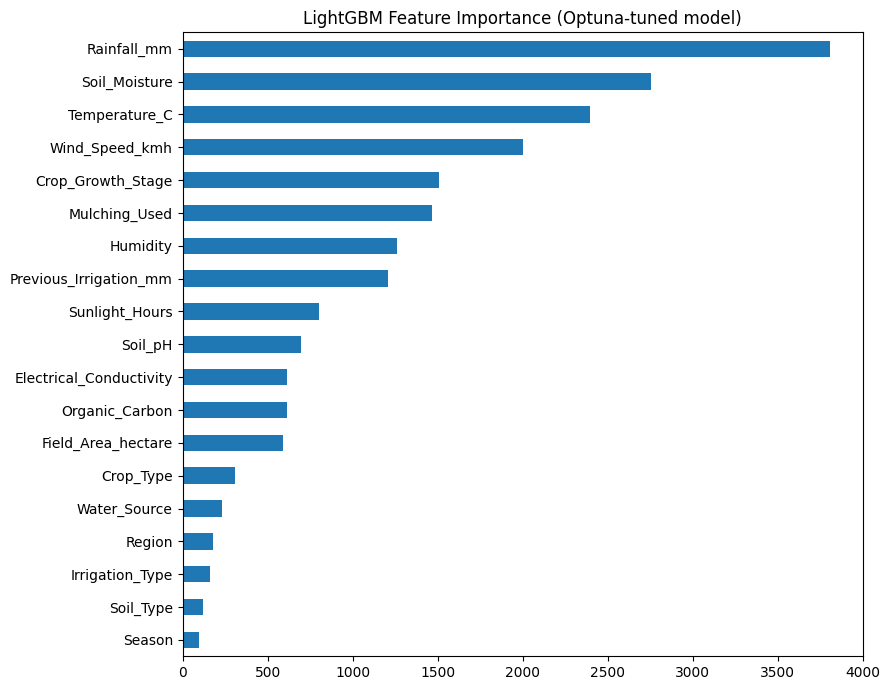


Top 5 features:
  Rainfall_mm: 3810
  Soil_Moisture: 2758
  Temperature_C: 2398
  Wind_Speed_kmh: 2004
  Crop_Growth_Stage: 1506


In [15]:
importances = pd.Series(lgb_best.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(9, 7), title='LightGBM Feature Importance (Optuna-tuned model)')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat}: {imp}')

### Feature importance discussion

The top 5 features by split count are Rainfall_mm (3810), Soil_Moisture (2758), Temperature_C (2398), Wind_Speed_kmh (2004), and Crop_Growth_Stage (1506). These are exactly 5 of the 6 features from Chris Deotte's "Original Data Exact Formula" notebook, which showed the original dataset's target is fully determined by Soil_Moisture, Temperature_C, Rainfall_mm, Wind_Speed_kmh, Crop_Growth_Stage, and Mulching_Used.

The 6th Deotte feature (Mulching_Used) is likely ranked just below the top 5. The remaining features (Soil_pH, Humidity, Region, etc.) have much lower importance, confirming they are noise introduced during synthetic data generation. LightGBM is finding the real signal in the data.

---
## Generate submission

In [16]:
lgb_final = LGBMClassifier(**study.best_params, random_state=42, verbose=-1, n_jobs=-1)
lgb_final.fit(X, y_enc)
preds = lgb_final.predict(X_test)
preds_labels = target_le.inverse_transform(preds)

submission = sample_sub.copy()
submission['Irrigation_Need'] = preds_labels
submission.to_csv('/kaggle/working/lightgbm_submission.csv', index=False)
print('Prediction distribution:')
print(submission['Irrigation_Need'].value_counts())
print()
print(submission.head())

Prediction distribution:
Irrigation_Need
Low       159615
Medium    100417
High        9968
Name: count, dtype: int64

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
